# Лабораторная 1: Абляционное исследование BatchNorm и Dropout

## Цели

1. Понять, как Batch Normalization и Dropout влияют на обучение нейронных сетей.
2. Изучить влияние размера батча на модели с Batch Normalization.
3. Провести факторный эксперимент (BN  × Dropout) на задачах нелинейной регрессии.
4. Сравнить динамику обучения, разрыв обобщения и качество предсказаний для различных конфигураций.

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
import pickle
from collections import defaultdict

In [22]:
# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Глобальные гиперпараметры

In [23]:
HIDDEN_DIM = 64
LR = 1e-3
EPOCHS = 200
DROPOUT_P = 0.2
BATCH_SIZES = [16, 64, 256]
TEST_RATIO = 0.2

## Раздел 1: Генерация данных

| Функция | Формула | Диапазон x | Шум σ | N | Почему сложная |
|----------|---------|---------|---------|---|---------------|
| **HiFreqSin** | y = sin(10πx) | [0, 1] | 0.15 | 500 | Частота в 5 раз выше — много осцилляций для аппроксимации |
| **Runge** | y = 1 / (1 + 25x²) | [−1, 1] | 0.10 | 500 | Классическая труднопприближаемая функция с острым центральным пиком |
| **MultiScale** | y = sin(2πx) + 0.5·sin(6πx) + 0.25·sin(14πx) | [0, 1] | 0.15 | 500 | Суперпозиция 3 частот — модель должна уловить несколько масштабов |

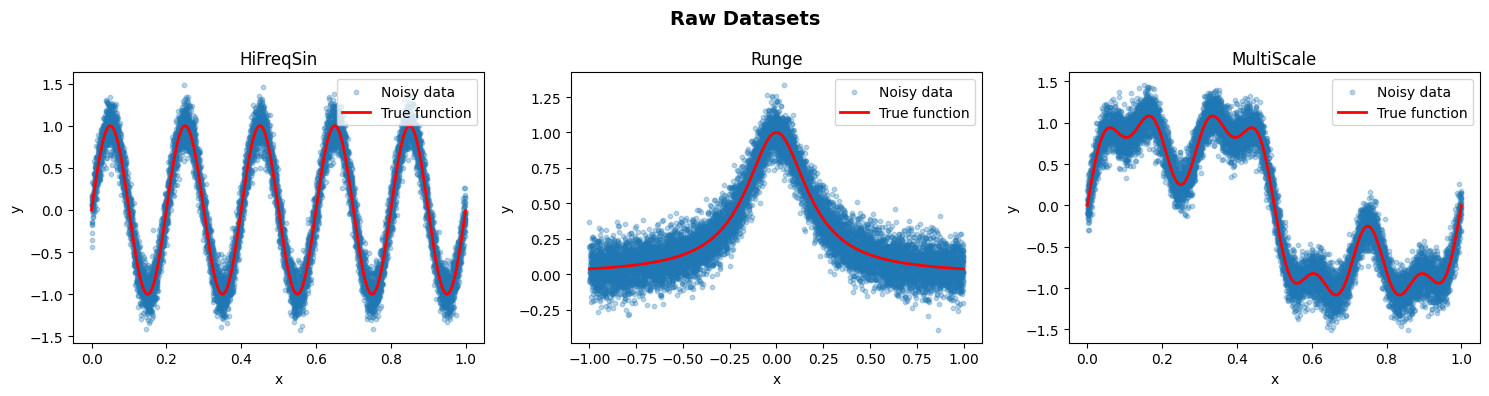

In [24]:
def generate_datasets(n=10_000, seed=SEED):
    rng = np.random.RandomState(seed)

    # HiFreqSin dataset — 5x the frequency of a standard sin
    x_hfs = rng.uniform(0, 1, n)
    y_hfs_true = np.sin(10 * np.pi * x_hfs)
    y_hfs = y_hfs_true + rng.normal(0, 0.15, n)

    # Runge dataset — classic hard-to-approximate function
    x_runge = rng.uniform(-1, 1, n)
    y_runge_true = 1.0 / (1.0 + 25.0 * x_runge**2)
    y_runge = y_runge_true + rng.normal(0, 0.10, n)

    # MultiScale dataset — superposition of 3 frequencies
    x_ms = rng.uniform(0, 1, n)
    y_ms_true = (np.sin(2 * np.pi * x_ms)
                 + 0.5 * np.sin(6 * np.pi * x_ms)
                 + 0.25 * np.sin(14 * np.pi * x_ms))
    y_ms = y_ms_true + rng.normal(0, 0.15, n)

    datasets = {
        'HiFreqSin': (x_hfs, y_hfs, y_hfs_true),
        'Runge': (x_runge, y_runge, y_runge_true),
        'MultiScale': (x_ms, y_ms, y_ms_true),
    }
    return datasets

datasets = generate_datasets()

# Plot raw data with true functions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, (x, y, y_true)) in zip(axes, datasets.items()):
    order = np.argsort(x)
    ax.scatter(x, y, alpha=0.3, s=10, label='Noisy data')
    ax.plot(x[order], y_true[order], 'r-', linewidth=2, label='True function')
    ax.set_title(name)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()
fig.suptitle('Raw Datasets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
def make_dataloaders(x, y, batch_size, test_ratio=TEST_RATIO, seed=SEED):
    """Convert numpy arrays to train/test DataLoaders."""
    X_t = torch.tensor(x, dtype=torch.float32).unsqueeze(1)
    Y_t = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    ds = TensorDataset(X_t, Y_t)

    n_test = int(len(ds) * test_ratio)
    n_train = len(ds) - n_test
    train_ds, test_ds = random_split(
        ds, [n_train, n_test],
        generator=torch.Generator().manual_seed(seed)
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

## Раздел 2: Модель


In [26]:
class MLP(nn.Module):
    def __init__(self, layer_num=3, hidden_dim=HIDDEN_DIM, use_batchnorm=False, use_dropout=False, dropout_p=DROPOUT_P):
        super().__init__()

        hidden_layers = []
        for i in range(layer_num):
          hidden_layers.append(nn.Linear(1 if i == 0 else hidden_dim, hidden_dim))
          if use_batchnorm:
              hidden_layers.append(nn.BatchNorm1d(hidden_dim))
          hidden_layers.append(nn.ReLU())
          if use_dropout:
              hidden_layers.append(nn.Dropout(dropout_p))

        self.net = nn.Sequential(*hidden_layers, nn.Linear(hidden_dim, 1))

    def forward(self, x):
        return self.net(x)

print(MLP(layer_num=3, use_batchnorm=True, use_dropout=True))

MLP(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [27]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    n_samples = 0
    for X_batch, Y_batch in loader:
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, Y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
        n_samples += X_batch.size(0)
    return total_loss / n_samples


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    n_samples = 0
    with torch.no_grad():
        for X_batch, Y_batch in loader:
            X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
            pred = model(X_batch)
            loss = criterion(pred, Y_batch)
            total_loss += loss.item() * X_batch.size(0)
            n_samples += X_batch.size(0)
    return total_loss / n_samples


def run_experiment(train_loader, test_loader, use_batchnorm, use_dropout,
                   epochs=EPOCHS, lr=LR, seed=SEED):
    torch.manual_seed(seed)
    model = MLP(layer_num=10, use_batchnorm=use_batchnorm, use_dropout=use_dropout).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    train_losses, test_losses = [], []
    for epoch in range(epochs):
        tr_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        te_loss = evaluate(model, test_loader, criterion, device)
        train_losses.append(tr_loss)
        test_losses.append(te_loss)

    return model, train_losses, test_losses

---
## Часть 1: Исследование размера батча


**Размеры батча:** 16, 64, 256

Как размер батча взаимодействует с BatchNorm и влияет на скорость сходимости и итоговую ошибку на тесте?

### Train

In [28]:
p1_results = {}  # (dataset_name, batch_size) -> (model, train_losses, test_losses)

dataset_names = list(datasets.keys())

for ds_name in dataset_names:
    x, y, _ = datasets[ds_name]
    for bs in BATCH_SIZES:
        print(f"Training: {ds_name}, BS={bs}, BN=True, DO=False")
        train_loader, test_loader = make_dataloaders(x, y, batch_size=bs)
        model, tr_loss, te_loss = run_experiment(
            train_loader, test_loader, use_batchnorm=True, use_dropout=False
        )
        p1_results[(ds_name, bs)] = (model, tr_loss, te_loss)

print("Part 1 training complete!")

Training: HiFreqSin, BS=16, BN=True, DO=False
Training: HiFreqSin, BS=64, BN=True, DO=False
Training: HiFreqSin, BS=256, BN=True, DO=False
Training: Runge, BS=16, BN=True, DO=False
Training: Runge, BS=64, BN=True, DO=False
Training: Runge, BS=256, BN=True, DO=False
Training: MultiScale, BS=16, BN=True, DO=False
Training: MultiScale, BS=64, BN=True, DO=False
Training: MultiScale, BS=256, BN=True, DO=False
Part 1 training complete!


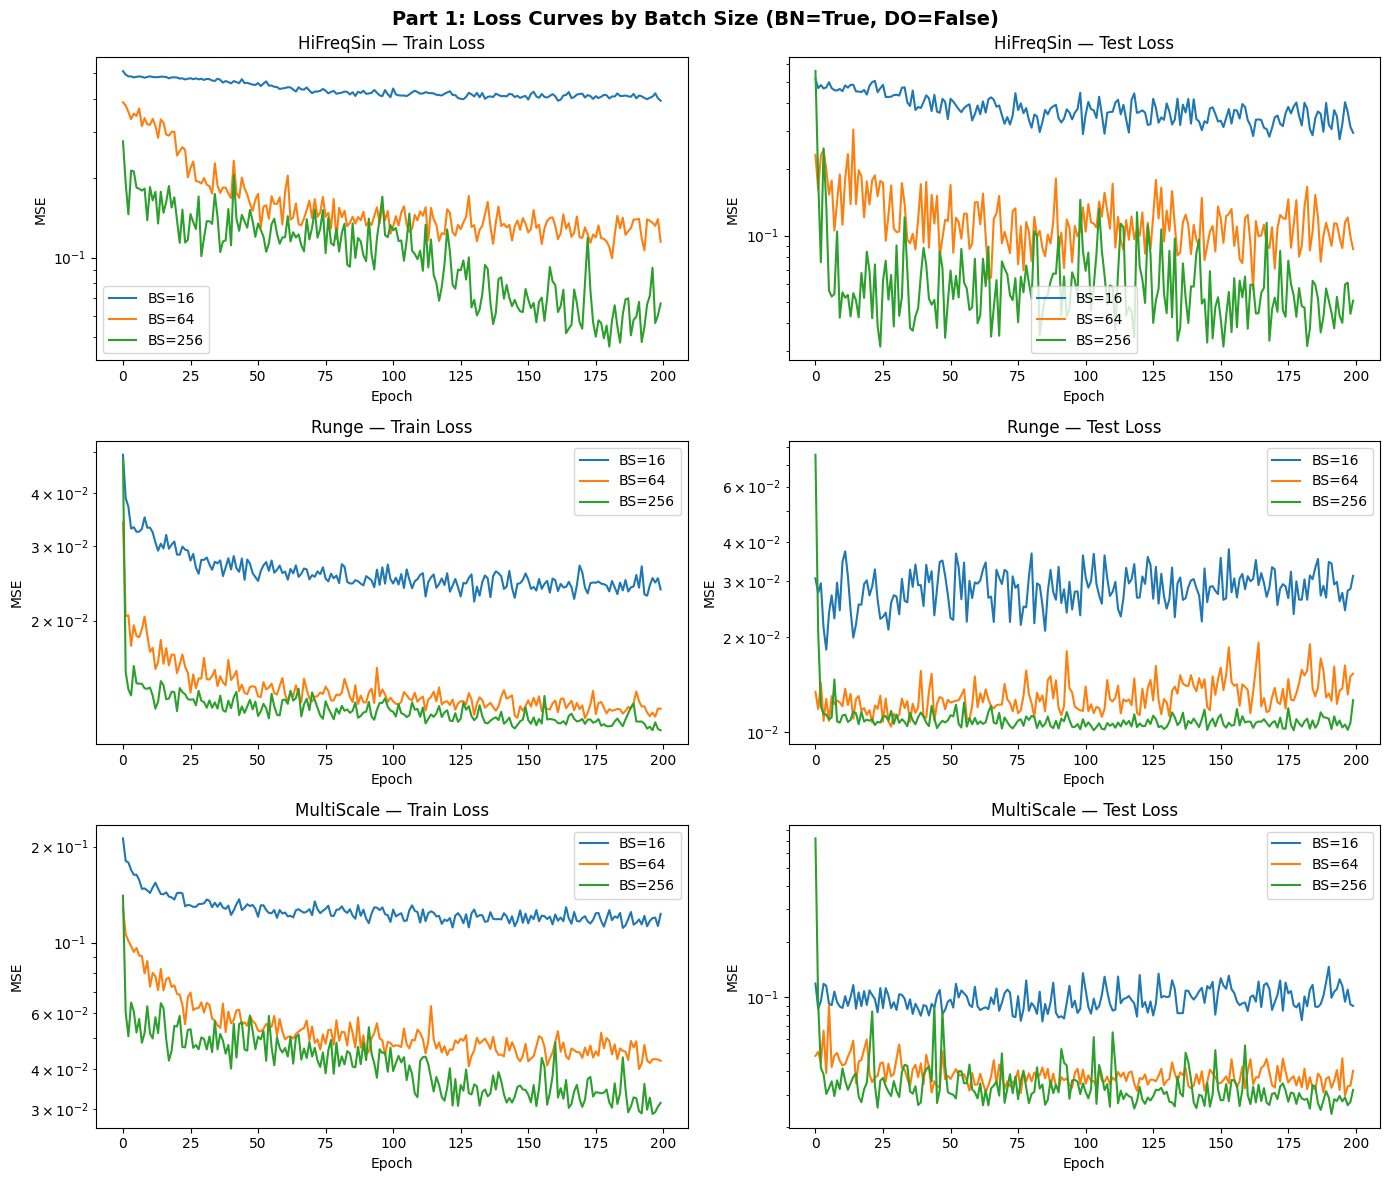

In [29]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for i, ds_name in enumerate(dataset_names):
    for bs in BATCH_SIZES:
        _, tr_loss, te_loss = p1_results[(ds_name, bs)]
        axes[i, 0].plot(tr_loss, label=f'BS={bs}')
        axes[i, 1].plot(te_loss, label=f'BS={bs}')

    axes[i, 0].set_title(f'{ds_name} — Train Loss')
    axes[i, 0].set_xlabel('Epoch')
    axes[i, 0].set_ylabel('MSE')
    axes[i, 0].legend()
    axes[i, 0].set_yscale('log')

    axes[i, 1].set_title(f'{ds_name} — Test Loss')
    axes[i, 1].set_xlabel('Epoch')
    axes[i, 1].set_ylabel('MSE')
    axes[i, 1].legend()
    axes[i, 1].set_yscale('log')

fig.suptitle('Part 1: Loss Curves by Batch Size (BN=True, DO=False)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Train results

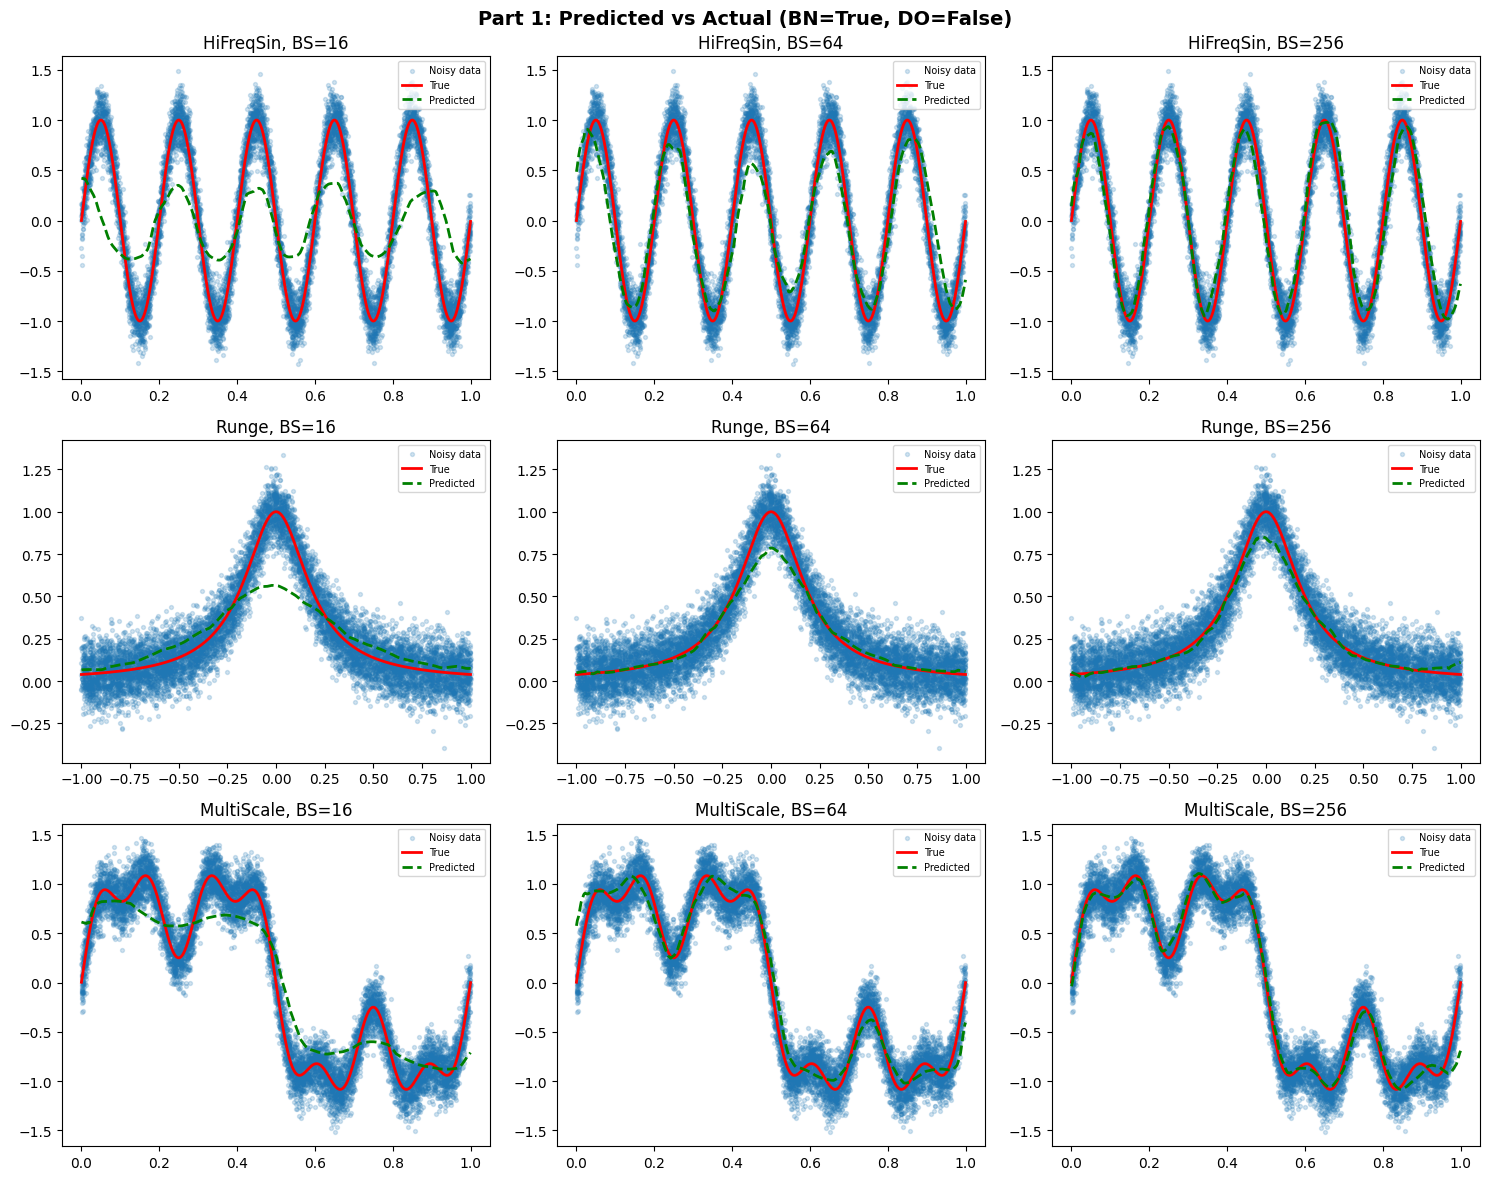

In [30]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for i, ds_name in enumerate(dataset_names):
    x, y, y_true = datasets[ds_name]
    order = np.argsort(x)
    x_sorted = x[order]

    for j, bs in enumerate(BATCH_SIZES):
        model, _, _ = p1_results[(ds_name, bs)]
        model.eval()
        x_tensor = torch.tensor(x_sorted, dtype=torch.float32).unsqueeze(1).to(device)
        with torch.no_grad():
            y_pred = model(x_tensor).cpu().numpy().flatten()

        axes[i, j].scatter(x, y, alpha=0.2, s=8, label='Noisy data')
        axes[i, j].plot(x_sorted, y_true[order], 'r-', linewidth=2, label='True')
        axes[i, j].plot(x_sorted, y_pred, 'g--', linewidth=2, label='Predicted')
        axes[i, j].set_title(f'{ds_name}, BS={bs}')
        axes[i, j].legend(fontsize=7)

fig.suptitle('Part 1: Predicted vs Actual (BN=True, DO=False)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

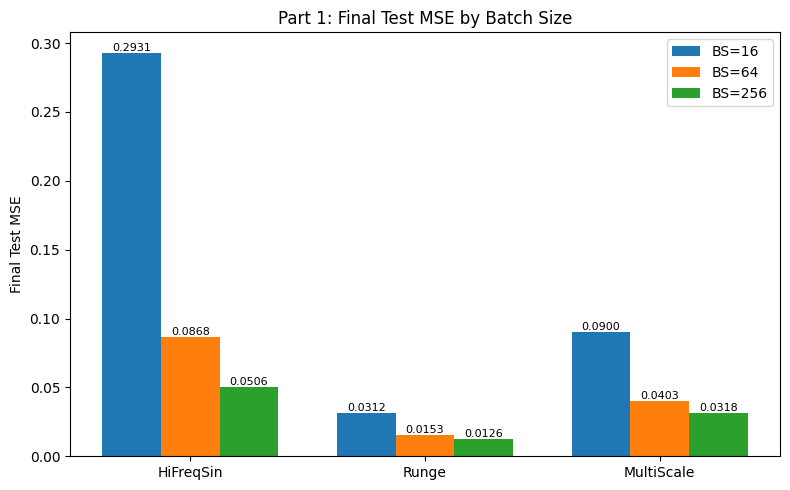


Average test MSE per batch size: {16: np.float64(0.13812750967716178), 64: np.float64(0.047452046041687325), 256: np.float64(0.03166332205881675)}
>>> BEST_BS = 256 (used in Part 2)


In [31]:
# Part 1: Bar chart of final test MSE + automatic BEST_BS selection
final_test_mse = {bs: [] for bs in BATCH_SIZES}

for ds_name in dataset_names:
    for bs in BATCH_SIZES:
        _, _, te_loss = p1_results[(ds_name, bs)]
        final_test_mse[bs].append(te_loss[-1])

# Bar chart
x_pos = np.arange(len(dataset_names))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
for k, bs in enumerate(BATCH_SIZES):
    bars = ax.bar(x_pos + k * width, final_test_mse[bs], width, label=f'BS={bs}')
    for bar, val in zip(bars, final_test_mse[bs]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x_pos + width)
ax.set_xticklabels(dataset_names)
ax.set_ylabel('Final Test MSE')
ax.set_title('Part 1: Final Test MSE by Batch Size')
ax.legend()
plt.tight_layout()
plt.show()

avg_mse = {bs: np.mean(vals) for bs, vals in final_test_mse.items()}
BEST_BS = min(avg_mse, key=avg_mse.get)
print(f"\nAverage test MSE per batch size: {avg_mse}")
print(f">>> BEST_BS = {BEST_BS} (used in Part 2)")

### Выводы по Части 1

**Ответьте на следующие вопросы:**

1. **Q**: Какой размер батча дал наименьшую среднюю ошибку на тесте? Почему так могло произойти?
  **A**: 256 - нормализация позволяет обучаться быстрее и достигать меньшего конечного MSE
2. **Q:** Как размер батча влияет на скорость сходимости? **A:** Зачастую ускоряет, но не всегда


---
## Часть 2

Используя лучший размер батча из Части 1, мы проводим новые эксперимеенты

| Вариант | BatchNorm | Dropout | Описание |
|---------|-----------|---------|-------------|
| Baseline | ✘ | ✘ | Без регуляризации |
| BN only | ✔ | ✘ | Только Batch Normalization |
| DO only | ✘ | ✔ | Только Dropout |
| BN + DO | ✔ | ✔ | Оба метода вместе |


### Training

In [32]:
variants = [
    ('Baseline', False, False),
    ('BN only', True, False),
    ('DO only', False, True),
    ('BN + DO', True, True),
]

p2_results = {}  # (variant_name, dataset_name) -> (model, train_losses, test_losses)

print(f"Using BEST_BS = {BEST_BS} from Part 1\n")

for var_name, use_bn, use_do in variants:
    for ds_name in dataset_names:
        x, y, _ = datasets[ds_name]
        print(f"Training: {var_name} on {ds_name}")
        train_loader, test_loader = make_dataloaders(x, y, batch_size=BEST_BS)
        model, tr_loss, te_loss = run_experiment(
            train_loader, test_loader, use_batchnorm=use_bn, use_dropout=use_do
        )
        p2_results[(var_name, ds_name)] = (model, tr_loss, te_loss)

print("\nPart 2 training complete!")

Using BEST_BS = 256 from Part 1

Training: Baseline on HiFreqSin
Training: Baseline on Runge
Training: Baseline on MultiScale
Training: BN only on HiFreqSin
Training: BN only on Runge
Training: BN only on MultiScale
Training: DO only on HiFreqSin
Training: DO only on Runge
Training: DO only on MultiScale
Training: BN + DO on HiFreqSin
Training: BN + DO on Runge
Training: BN + DO on MultiScale

Part 2 training complete!


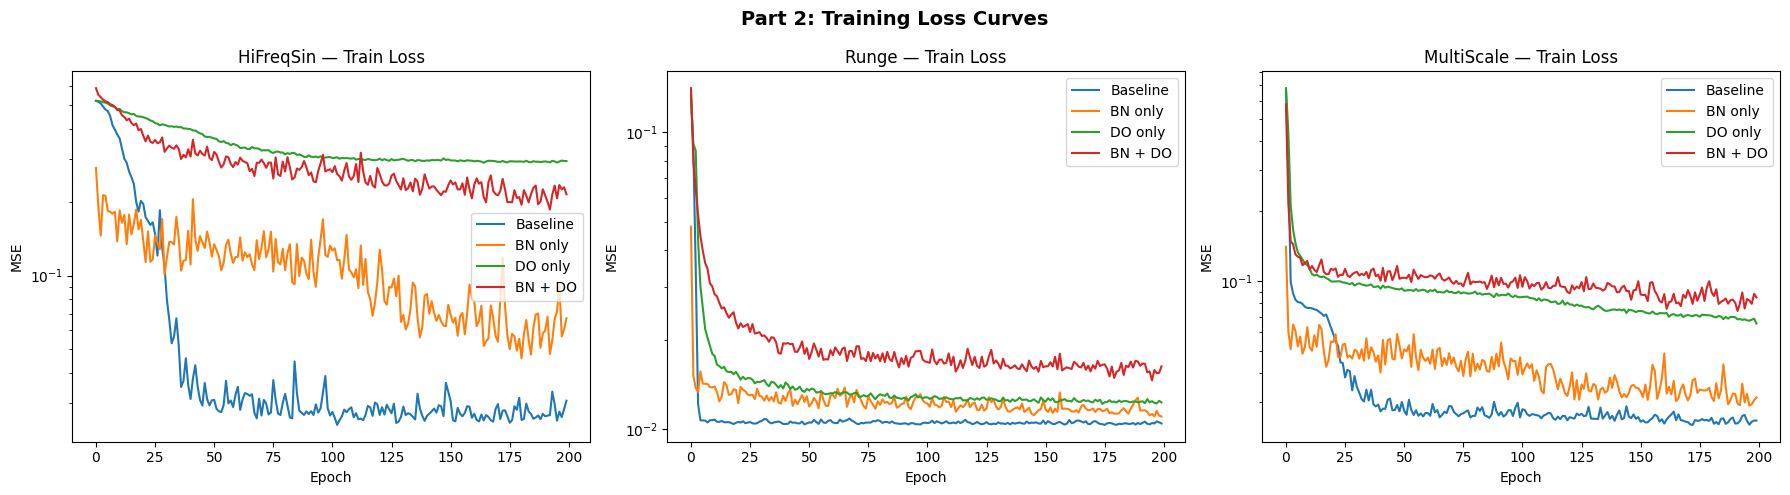

In [33]:
variant_names = [v[0] for v in variants]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for j, ds_name in enumerate(dataset_names):
    for k, var_name in enumerate(variant_names):
        _, tr_loss, _ = p2_results[(var_name, ds_name)]
        axes[j].plot(tr_loss, label=var_name, color=colors[k])
    axes[j].set_title(f'{ds_name} — Train Loss')
    axes[j].set_xlabel('Epoch')
    axes[j].set_ylabel('MSE')
    axes[j].legend()
    axes[j].set_yscale('log')

fig.suptitle('Part 2: Training Loss Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

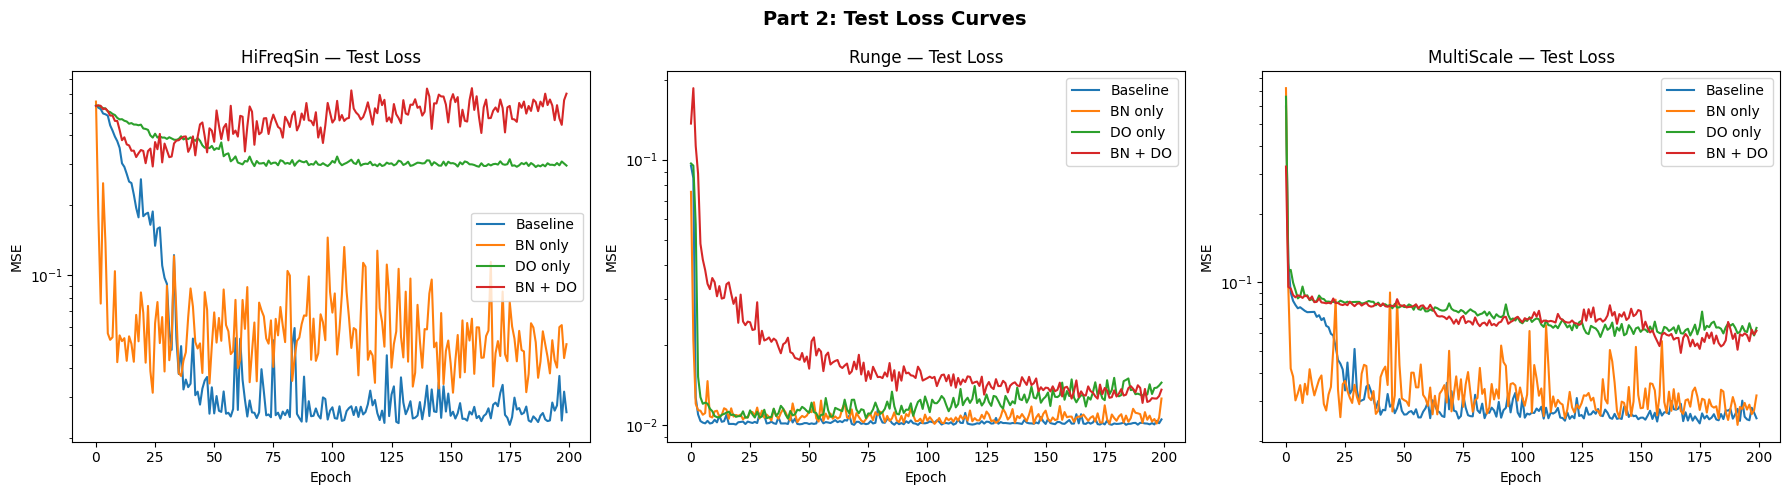

In [34]:
# Part 2: Test loss curves — 1x3
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for j, ds_name in enumerate(dataset_names):
    for k, var_name in enumerate(variant_names):
        _, _, te_loss = p2_results[(var_name, ds_name)]
        axes[j].plot(te_loss, label=var_name, color=colors[k])
    axes[j].set_title(f'{ds_name} — Test Loss')
    axes[j].set_xlabel('Epoch')
    axes[j].set_ylabel('MSE')
    axes[j].legend()
    axes[j].set_yscale('log')

fig.suptitle('Part 2: Test Loss Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Training result

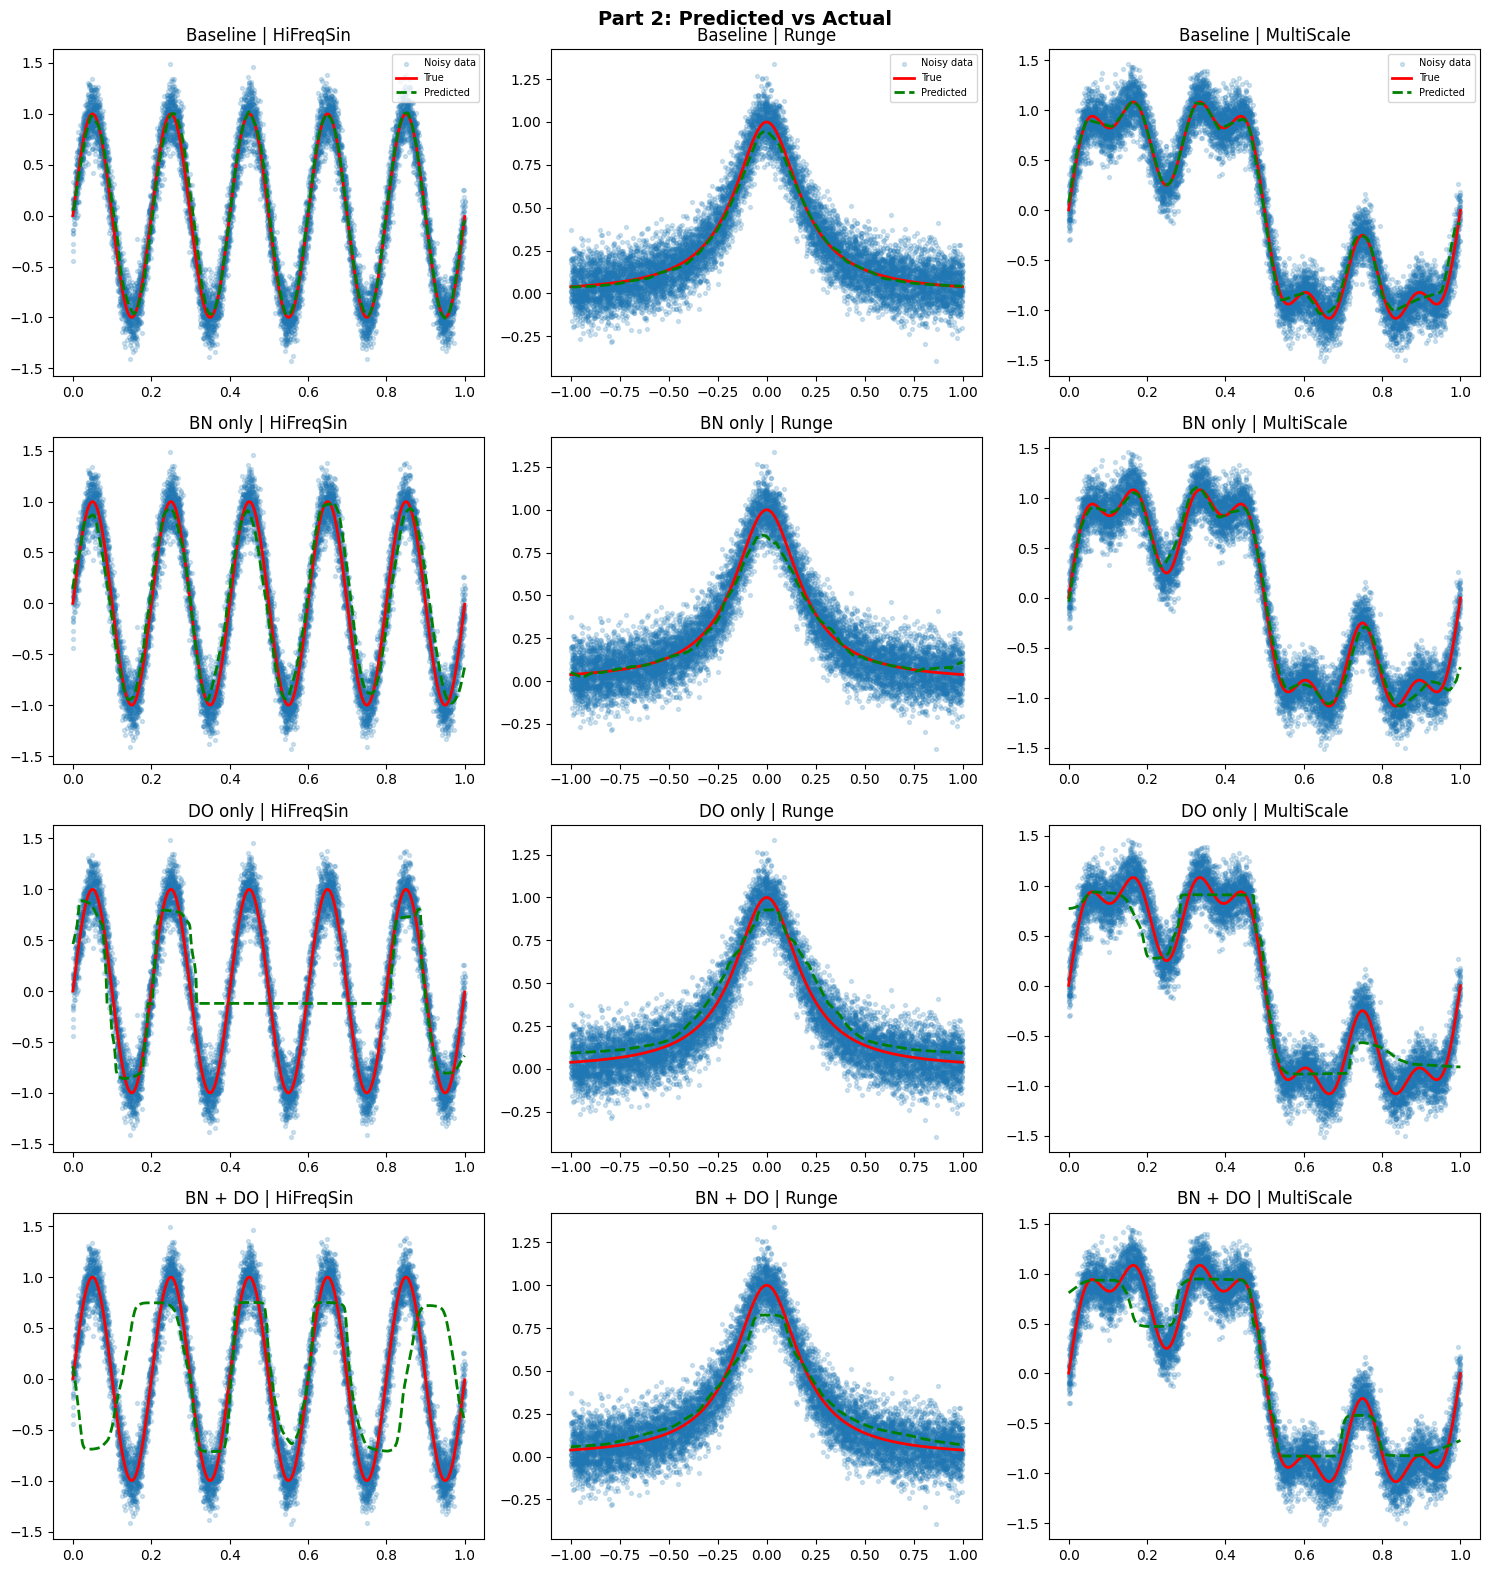

In [35]:
fig, axes = plt.subplots(4, 3, figsize=(15, 16))

for i, var_name in enumerate(variant_names):
    for j, ds_name in enumerate(dataset_names):
        x, y, y_true = datasets[ds_name]
        order = np.argsort(x)
        x_sorted = x[order]

        model, _, _ = p2_results[(var_name, ds_name)]
        model.eval()
        x_tensor = torch.tensor(x_sorted, dtype=torch.float32).unsqueeze(1).to(device)
        with torch.no_grad():
            y_pred = model(x_tensor).cpu().numpy().flatten()

        axes[i, j].scatter(x, y, alpha=0.2, s=8, label='Noisy data')
        axes[i, j].plot(x_sorted, y_true[order], 'r-', linewidth=2, label='True')
        axes[i, j].plot(x_sorted, y_pred, 'g--', linewidth=2, label='Predicted')
        axes[i, j].set_title(f'{var_name} | {ds_name}')
        if i == 0:
            axes[i, j].legend(fontsize=7)

fig.suptitle('Part 2: Predicted vs Actual', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

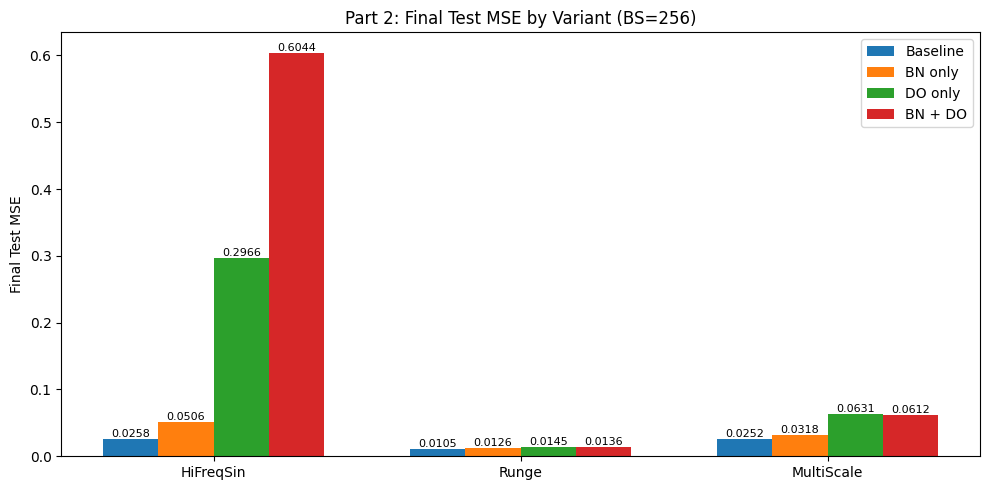

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(dataset_names))
width = 0.18

for k, var_name in enumerate(variant_names):
    mse_vals = [p2_results[(var_name, ds)][-1][-1] for ds in dataset_names]
    bars = ax.bar(x_pos + k * width, mse_vals, width, label=var_name, color=colors[k])
    for bar, val in zip(bars, mse_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x_pos + 1.5 * width)
ax.set_xticklabels(dataset_names)
ax.set_ylabel('Final Test MSE')
ax.set_title(f'Part 2: Final Test MSE by Variant (BS={BEST_BS})')
ax.legend()
plt.tight_layout()
plt.show()

In [37]:
# Part 2: Numeric summary table
print(f"{'Variant':<12} {'Dataset':<8} {'Final Train MSE':>16} {'Final Test MSE':>16} {'Gap':>12}")
print('-' * 68)

for var_name in variant_names:
    for ds_name in dataset_names:
        _, tr_loss, te_loss = p2_results[(var_name, ds_name)]
        gap = te_loss[-1] - tr_loss[-1]
        print(f"{var_name:<12} {ds_name:<8} {tr_loss[-1]:>16.6f} {te_loss[-1]:>16.6f} {gap:>12.6f}")
    print()

# Rank variants by average test MSE
print("\n=== Ranking by Average Test MSE ===")
avg_scores = {}
for var_name in variant_names:
    vals = [p2_results[(var_name, ds)][-1][-1] for ds in dataset_names]
    avg_scores[var_name] = np.mean(vals)

for rank, (name, score) in enumerate(sorted(avg_scores.items(), key=lambda x: x[1]), 1):
    print(f"  {rank}. {name:<12} avg test MSE = {score:.6f}")

Variant      Dataset   Final Train MSE   Final Test MSE          Gap
--------------------------------------------------------------------
Baseline     HiFreqSin         0.030792         0.025817    -0.004975
Baseline     Runge            0.010448         0.010514     0.000065
Baseline     MultiScale         0.024975         0.025210     0.000235

BN only      HiFreqSin         0.066961         0.050609    -0.016351
BN only      Runge            0.011028         0.012601     0.001573
BN only      MultiScale         0.031417         0.031780     0.000363

DO only      HiFreqSin         0.294348         0.296615     0.002268
DO only      Runge            0.012300         0.014463     0.002163
DO only      MultiScale         0.065470         0.063093    -0.002377

BN + DO      HiFreqSin         0.215358         0.604401     0.389042
BN + DO      Runge            0.016261         0.013607    -0.002654
BN + DO      MultiScale         0.084881         0.061250    -0.023632


=== Ranking by Av

### Выводы по Части 2

**Эффект BatchNorm:**
- Сильно ускоряет схождение модели

**Эффект Dropout:**
- Должно быть, что ухудшает показатели train loss, но улучшает test loss, но что-то не всегда видимо
- Dropout не очень эффективен

**Комбинация (BN + DO):**
- На моих примерах - нет